In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/m5-forecasting-accuracy/calendar.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sample_submission.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sell_prices.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sales_train_validation.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sales_train_evaluation.csv
/kaggle/input/datasets/pavankumar9938/setttt/xgb_predictions.xls
/kaggle/input/datasets/pavankumar9938/setttt/sales_subset_15000.csv


In [5]:
# =============================================================================
# LSTM M5 FORECASTING — XGBoost-Aligned Feature Engineering
# =============================================================================
# Key changes vs original:
#   1. Feature engineering rewritten in long format to exactly match teammate's
#      XGBoost pipeline (same 52 features, same logic, same column names).
#   2. Trains on the OTHER 14000 products; evaluates only on the 1000 sample IDs
#      from xgb_predictions.csv (clean train/eval separation — no overlap).
#   3. Validation period fixed at d_1886–d_1913 (same as XGBoost).
#   4. Evaluation broken down at 7-day, 14-day, 28-day horizons.
#   5. Output CSV (lstm_predictions.csv) has an lstm_pred column and is ready
#      to merge with xgb_predictions.csv on (id, d) for the Gating Network.
# =============================================================================
 
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 – IMPORTS & KAGGLE PATHS
# ─────────────────────────────────────────────────────────────────────────────
import os
import gc
import tempfile
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
 
warnings.filterwarnings("ignore")
 
# ── Kaggle paths ──────────────────────────────────────────────────────────────
# Input datasets are read-only under /kaggle/input/<dataset-slug>/
# All outputs (models, CSVs, plots) go to /kaggle/working/ which is persisted.
#
# Expected dataset structure on Kaggle:
#   /kaggle/input/m5-forecasting-accuracy/
#       sales_subset_15000.csv
#       calendar.csv
#       sell_prices.csv
#   /kaggle/input/m5-xgb-predictions/      ← upload xgb_predictions.csv here
#       xgb_predictions.csv
 
DATA_DIR   = Path("/kaggle/input/competitions/m5-forecasting-accuracy")  # raw M5 files
XGB_DIR    = Path("/kaggle/input/datasets/pavankumar9938/setttt/xgb_predictions.xls")       # teammate's output
OUTPUT_DIR = Path("/kaggle/working")                         # all LSTM outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
# ── Global constants (must match teammate's XGBoost notebook exactly) ─────────
TRAIN_START_DAY = 1500   # d_1500 onwards for training
VAL_START_DAY   = 1886   # d_1886 first validation day
VAL_END_DAY     = 1913   # d_1913 last validation day
SEQ_LEN         = 28
STRIDE          = 14              # lookback window fed to LSTM (28 days)
HORIZON         = 28     # forecast horizon (28 days = M5 standard)
RANDOM_SEED     = 42
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[OK] Device: {DEVICE}")

[OK] Device: cuda


In [6]:
# =============================================================================
# SECTION 1 – LOAD RAW DATA
# =============================================================================
print("\n--- Loading raw data ---")
sales     = pd.read_csv('/kaggle/input/datasets/pavankumar9938/setttt/sales_subset_15000.csv')
calendar  = pd.read_csv(DATA_DIR / "calendar.csv", parse_dates=["date"])
prices    = pd.read_csv(DATA_DIR / "sell_prices.csv")
 
# Load XGBoost predictions to get the exact 1000 evaluation IDs
xgb_preds  = pd.read_csv(XGB_DIR)
SAMPLE_IDS = set(xgb_preds["id"].unique())          # 1000 eval products
TRAIN_IDS  = set(sales["id"].unique()) - SAMPLE_IDS  # remaining ~14000 train products
print(f"  Total products : {len(SAMPLE_IDS) + len(TRAIN_IDS)}")
print(f"  Train products : {len(TRAIN_IDS)}")
print(f"  Eval  products : {len(SAMPLE_IDS)}  (from xgb_predictions.csv)")
# ⚠️  Do NOT filter sales here — all 15000 products go through feature
# engineering so that group-level features (price_relative, etc.) are
# computed correctly across the full population.
 
# =============================================================================
# SECTION 2 – MELT WIDE → LONG (identical to teammate's step 1.3)
# =============================================================================
print("\n--- Melting wide → long format ---")
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
d_cols  = [c for c in sales.columns if c.startswith("d_")]
 
df = sales.melt(id_vars=id_cols, value_vars=d_cols,
                var_name="d", value_name="sales")
del sales; gc.collect()
print(f"  Long-format shape: {df.shape}")
 
# =============================================================================
# SECTION 3 – MERGE CALENDAR & PRICES (identical to teammate's steps 1.4–1.5)
# =============================================================================
print("\n--- Merging calendar and prices ---")
df = df.merge(calendar, on="d", how="left")
df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
del prices; gc.collect()
print(f"  Merged shape: {df.shape}")
 
# =============================================================================
# SECTION 4 – DATA TYPE OPTIMISATION (identical to teammate's step 1.6)
# =============================================================================
print("\n--- Optimising dtypes ---")
df["d_num"] = df["d"].str.extract(r"(\d+)").astype(np.int16)
df["sales"]   = df["sales"].astype(np.int16)
df["wday"]    = df["wday"].astype(np.int8)
df["month"]   = df["month"].astype(np.int8)
df["year"]    = df["year"].astype(np.int16)
df["snap_CA"] = df["snap_CA"].astype(np.int8)
df["snap_TX"] = df["snap_TX"].astype(np.int8)
df["snap_WI"] = df["snap_WI"].astype(np.int8)
 
for col in ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id",
            "d", "weekday", "event_name_1", "event_type_1",
            "event_name_2", "event_type_2"]:
    df[col] = df[col].astype("category")
 
df.sort_values(["id", "d_num"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
 
# =============================================================================
# SECTION 5 – FEATURE ENGINEERING
# Exact mirror of teammate's XGBoost feature engineering.
# All 52 features built here; same column names, same logic.
# =============================================================================
print("\n--- Feature engineering (aligned with XGBoost teammate) ---")
 
# ── 5.1 Price features (teammate's step 1.6b) ──────────────────────────────
print("  [1/8] Price features...")
df["sell_price"] = df.groupby("id")["sell_price"].ffill().fillna(0)
df["price_rolling_mean"] = (
    df.groupby("id")["sell_price"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)
df["price_change"]    = (df["sell_price"] - df["price_rolling_mean"]).fillna(0)
cat_store_price       = df.groupby(["cat_id", "store_id", "d"])["sell_price"].transform("mean")
df["price_relative"]  = (df["sell_price"] / (cat_store_price + 1e-8)).fillna(1.0).astype(np.float32)
df["is_discounted"]   = (
    (df["sell_price"] < 0.9 * df["price_rolling_mean"]) & (df["sell_price"] > 0)
).astype(np.int8)
df.drop(columns=["price_rolling_mean"], inplace=True)
 
# ── 5.2 Lag features (teammate's step 2.1) ─────────────────────────────────
print("  [2/8] Lag features...")
for lag in [1, 2, 3, 7, 14, 28]:
    df[f"lag_{lag}"] = df.groupby("id")["sales"].shift(lag)
 
# ── 5.3 Rolling averages (teammate's step 2.2) ──────────────────────────────
print("  [3/8] Rolling averages...")
for window in [7, 14, 28, 60]:
    df[f"rolling_mean_{window}"] = (
        df.groupby("id")["sales"]
        .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=1).mean())
    )
 
# ── 5.4 Rolling variance (teammate's step 2.3) ──────────────────────────────
print("  [4/8] Rolling variance...")
for window in [7, 14, 28]:
    df[f"rolling_var_{window}"] = (
        df.groupby("id")["sales"]
        .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=1).var())
    )
 
# ── 5.5 Volatility indicators (teammate's step 2.4) ─────────────────────────
print("  [5/8] Volatility indicators...")
df["rolling_std_28"] = (
    df.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).rolling(28, min_periods=1).std())
)
df["cv_28"]        = df["rolling_std_28"] / (df["rolling_mean_28"] + 1e-8)
df["expanding_std"] = (
    df.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).expanding(min_periods=2).std())
)
df["momentum_7_28"] = df["rolling_mean_7"] / (df["rolling_mean_28"] + 1e-8)
 
# ── 5.6 Event flags (teammate's step 2.5) ───────────────────────────────────
print("  [6/8] Event flags...")
df["has_event_1"]       = df["event_name_1"].notna().astype(np.int8)
df["has_event_2"]       = df["event_name_2"].notna().astype(np.int8)
df["has_any_event"]     = ((df["has_event_1"] == 1) | (df["has_event_2"] == 1)).astype(np.int8)
df["event_type_1_enc"]  = df["event_type_1"].cat.codes.astype(np.int8)
df["event_type_2_enc"]  = df["event_type_2"].cat.codes.astype(np.int8)
 
# ── 5.7 SNAP features (teammate's step 2.6) ─────────────────────────────────
print("  [7/8] SNAP features...")
df["snap_active"] = np.where(
    df["state_id"] == "CA", df["snap_CA"],
    np.where(df["state_id"] == "TX", df["snap_TX"], df["snap_WI"])
).astype(np.int8)
df["snap_x_food"]    = ((df["snap_active"] == 1) & (df["cat_id"] == "FOODS")).astype(np.int8)
df["snap_rolling_7"] = (
    df.groupby("id")["snap_active"]
    .transform(lambda x: x.rolling(7, min_periods=1).sum())
).astype(np.int8)
 
# ── 5.8 Calendar + interaction features (teammate's steps 2.7 & 2.6b) ───────
print("  [8/8] Calendar & interaction features...")
df["day_of_month"]      = df["date"].dt.day.astype(np.int8)
df["week_of_year"]      = df["date"].dt.isocalendar().week.astype(np.int8)
df["is_weekend"]        = ((df["wday"] == 1) | (df["wday"] == 2)).astype(np.int8)
df["is_month_start"]    = df["date"].dt.is_month_start.astype(np.int8)
df["is_month_end"]      = df["date"].dt.is_month_end.astype(np.int8)
df["quarter"]           = df["date"].dt.quarter.astype(np.int8)
df["is_fortnight_2"]    = (df["day_of_month"] > 15).astype(np.int8)
df["fortnight_of_year"] = ((df["month"] - 1) * 2 + df["is_fortnight_2"]).astype(np.int8)
df["weekend_rolling_7"] = (
    df.groupby("id")["is_weekend"]
    .transform(lambda x: x.rolling(7, min_periods=1).sum())
).astype(np.int8)
df["weekend_rolling_14"] = (
    df.groupby("id")["is_weekend"]
    .transform(lambda x: x.rolling(14, min_periods=1).sum())
).astype(np.int8)
df["days_since_weekend"] = np.where(
    df["is_weekend"] == 1, 0, np.clip(df["wday"].astype(int) - 2, 0, 5)
).astype(np.int8)
 
# Interaction features
df["snap_x_weekend"]  = (df["snap_active"] * df["is_weekend"]).astype(np.int8)
df["event_x_food"]    = ((df["has_any_event"] == 1) & (df["cat_id"] == "FOODS")).astype(np.int8)
df["weekend_x_food"]  = ((df["is_weekend"] == 1) & (df["cat_id"] == "FOODS")).astype(np.int8)
df["monthend_x_snap"] = (df["is_month_end"] * df["snap_active"]).astype(np.int8)
 
# ── 5.9 Categorical label encoding ──────────────────────────────────────────
for col in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]:
    df[f"{col}_enc"] = df[col].cat.codes.astype(np.int16)
 
print(f"\n  Dataset shape after feature engineering: {df.shape}")
 
# =============================================================================
# SECTION 6 – DEFINE FEATURE COLUMNS
# Exact same 52-column list as teammate's FEATURE_COLS.
# These become the per-timestep features in each LSTM input sequence.
# =============================================================================
FEATURE_COLS = (
    [f"{c}_enc" for c in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]]
    + [f"lag_{l}" for l in [1, 2, 3, 7, 14, 28]]
    + [f"rolling_mean_{w}" for w in [7, 14, 28, 60]]
    + [f"rolling_var_{w}" for w in [7, 14, 28]]
    + ["rolling_std_28", "cv_28", "expanding_std", "momentum_7_28"]
    + ["has_event_1", "has_event_2", "has_any_event",
       "event_type_1_enc", "event_type_2_enc"]
    + ["snap_active", "snap_x_food", "snap_rolling_7"]
    + ["snap_x_weekend", "event_x_food", "weekend_x_food", "monthend_x_snap"]
    + ["wday", "month", "year", "day_of_month", "week_of_year",
       "is_weekend", "is_month_start", "is_month_end", "quarter"]
    + ["is_fortnight_2", "fortnight_of_year",
       "weekend_rolling_7", "weekend_rolling_14", "days_since_weekend"]
    + ["sell_price", "price_change", "price_relative", "is_discounted"]
)
assert len(FEATURE_COLS) == 52, f"Expected 52 features, got {len(FEATURE_COLS)}"
print(f"\n[OK] Feature columns verified: {len(FEATURE_COLS)} features")
 
# =============================================================================
# SECTION 7 – PREPARE TRAINING SUBSET & FILL NaNs
# =============================================================================
print("\n--- Preparing training subset ---")
# Use the same d >= 1500 filter as teammate (lag features valid here)
df_model = df[df["d_num"] >= TRAIN_START_DAY].copy()
 
# Fill any residual NaNs with 0 (same as teammate)
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(0)
df_model["sales"]      = df_model["sales"].fillna(0).astype(np.float32)
 
print(f"  Model subset shape : {df_model.shape}")
print(f"  d_num range        : {df_model['d_num'].min()} – {df_model['d_num'].max()}")
 
# =============================================================================
# SECTION 8 – SEQUENCE GENERATION
# For each ID:
#   • Training  : sliding windows of (SEQ_LEN input days → HORIZON target days)
#                 over d_1500 to d_1885
#   • Validation: one window per ID  →  input d_1826–d_1885, target d_1886–d_1913
# =============================================================================
print("\n--- Generating sequences ---")
 
# ── Batch partial_fit scaler on 14000 train products ─────────────────────────
# Avoids loading all 14000 × 385 rows (~14M rows × 52 features) into RAM at once.
# StandardScaler.partial_fit() accumulates running mean/var across batches and
# produces exactly the same result as a single fit() — just without the RAM spike.
#
# Only training products (not in SAMPLE_IDS) and only pre-validation days
# (d_1500–d_1885) are used, so no eval information leaks into normalisation.
 
SCALER_BATCH_SIZE = 500          # products per batch; tune down if RAM is still tight
train_id_list     = list(TRAIN_IDS)
scaler            = StandardScaler()
total_rows_seen   = 0
 
print(f"  Fitting scaler in batches of {SCALER_BATCH_SIZE} products …")
for batch_start in range(0, len(train_id_list), SCALER_BATCH_SIZE):
    batch_ids = train_id_list[batch_start : batch_start + SCALER_BATCH_SIZE]
 
    # Pull only this batch's rows that fall in the training day window
    batch_mask = (
        df_model["id"].isin(batch_ids)        &
        (df_model["d_num"] >= TRAIN_START_DAY) &
        (df_model["d_num"] <  VAL_START_DAY)
    )
    batch_data = df_model.loc[batch_mask, FEATURE_COLS].values.astype(np.float32)
 
    if len(batch_data) == 0:
        continue
 
    scaler.partial_fit(batch_data)   # accumulates mean/var without storing the batch
    total_rows_seen += len(batch_data)
 
    batch_num = batch_start // SCALER_BATCH_SIZE + 1
    total_batches = (len(train_id_list) + SCALER_BATCH_SIZE - 1) // SCALER_BATCH_SIZE
    print(f"    batch {batch_num:3d}/{total_batches}  "
          f"({len(batch_ids)} products, {len(batch_data):,} rows)", end="\r")
 
    del batch_data; gc.collect()
 
print(f"\n  Scaler fitted via partial_fit: {total_rows_seen:,} rows "
      f"from {len(TRAIN_IDS)} train products  ✓")
 
# ── Batch preprocessing constants ────────────────────────────────────────────
PREPROC_BATCH_SIZE = 500          # items per batch; lower → less RAM peak
MMAP_DIR           = tempfile.gettempdir()   # swap to a fast SSD path if available
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  Helper: count training windows for ONE item — no arrays allocated
# ─────────────────────────────────────────────────────────────────────────────
def _count_windows(d_nums: np.ndarray, val_start: int,
                   seq_len: int, horizon: int, stride: int = 1) -> int:
    n_train = int((d_nums < val_start).sum())
    n_full  = max(0, n_train - seq_len - horizon + 1)
    # ceil division: same formula DataLoader uses for drop_last=False
    return (n_full + stride - 1) // stride if n_full > 0 else 0
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  Core builder: process ONE BATCH of items, return compact numpy arrays
# ─────────────────────────────────────────────────────────────────────────────
def make_sequences_batch(
    grouped_batch,
    seq_len: int,
    horizon: int,
    val_start: int,
    val_end: int,
    scaler,
    feature_cols: list,
    train_ids: set,
    sample_ids: set,
    stride: int = 1,
):
    """
    Process a batch of (item_id, sorted_group_df) tuples in one sweep.
 
    Parameters
    ----------
    stride : int
        Step size for the sliding window over training days.
        stride=1  → every possible window  (maximum data, slowest training)
        stride=7  → one window per week    (~7× fewer windows)
        stride=14 → one window per fortnight (~14× fewer, fits 1-2 hr budget)
 
    Returns
    -------
    X_tr   : (N_windows, seq_len, n_feat) float32  or None
    y_tr   : (N_windows, horizon)         float32  or None
    X_ev   : (N_eval,    seq_len, n_feat) float32  or None
    y_ev   : (N_eval,    horizon)         float32  or None
    meta   : list of {"id": ..., "d_num": int} for each eval forecast day
    """
    Xt_buf, yt_buf = [], []
    Xe_buf, ye_buf = [], []
    meta            = []
 
    for item_id, grp in grouped_batch:
        # shared feature transform — done once per item
        feats  = scaler.transform(grp[feature_cols].values.astype(np.float32))
        sales  = grp["sales"].values.astype(np.float32)
        d_nums = grp["d_num"].values
 
        # ── TRAIN path ────────────────────────────────────────────────────
        if item_id in train_ids:
            tr_mask  = d_nums < val_start
            feats_tr = feats[tr_mask]
            sales_tr = sales[tr_mask]
            n        = len(feats_tr)
            for s in range(0, n - seq_len - horizon + 1, stride):
                Xt_buf.append(feats_tr[s : s + seq_len])
                yt_buf.append(sales_tr[s + seq_len : s + seq_len + horizon])
 
        # ── EVAL path ─────────────────────────────────────────────────────
        elif item_id in sample_ids:
            val_mask = (d_nums >= val_start) & (d_nums <= val_end)
            pre_mask = d_nums < val_start
            if pre_mask.sum() >= seq_len and val_mask.sum() == horizon:
                Xe_buf.append(feats[pre_mask][-seq_len:])   # (seq_len, n_feat)
                ye_buf.append(sales[val_mask])               # (horizon,)
                for d in d_nums[val_mask]:
                    meta.append({"id": item_id, "d_num": int(d)})
 
    X_tr = np.array(Xt_buf, dtype=np.float32) if Xt_buf else None
    y_tr = np.array(yt_buf, dtype=np.float32) if yt_buf else None
    X_ev = np.array(Xe_buf, dtype=np.float32) if Xe_buf else None
    y_ev = np.array(ye_buf, dtype=np.float32) if ye_buf else None
 
    return X_tr, y_tr, X_ev, y_ev, meta
 
 
# ═════════════════════════════════════════════════════════════════════════════
#  PHASE 1 — Count-only pass  (O(n) time, O(1) memory)
#             Iterates over TRAIN_IDS using only d_num — no feature transform,
#             no array building — to get the exact total window count so the
#             memmap can be pre-allocated to exactly the right shape.
# ═════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("Phase 1 | Counting training windows (no array allocation) …")
 
total_train_windows = 0
_count_df = df_model[df_model["id"].isin(TRAIN_IDS)][["id", "d_num"]]
for _item_id, _grp in _count_df.groupby("id", observed=True):
    total_train_windows += _count_windows(
        _grp["d_num"].values, VAL_START_DAY, SEQ_LEN, HORIZON, STRIDE
    )
 
n_feat     = len(FEATURE_COLS)
n_eval_ids = len(SAMPLE_IDS)
 
print(f"  Total training windows : {total_train_windows:>10,}")
print(f"  Train array shape      : ({total_train_windows:,}, {SEQ_LEN}, {n_feat})")
print(f"  Eval  array shape      : ({n_eval_ids}, {SEQ_LEN}, {n_feat})")
del _count_df; gc.collect()
 
 
# ═════════════════════════════════════════════════════════════════════════════
#  PHASE 2 — Allocate storage
#             Train sequences → np.memmap  (disk-backed, zero RAM overhead)
#             Eval  sequences → plain numpy array  (1000 × 28 × 52 ≈ 6 MB)
# ═════════════════════════════════════════════════════════════════════════════
print("\nPhase 2 | Allocating storage …")
 
_path_X = os.path.join(MMAP_DIR, "X_train_mmap.dat")
_path_y = os.path.join(MMAP_DIR, "y_train_mmap.dat")
 
# Remove stale files from any previous interrupted run
for _p in (_path_X, _path_y):
    if os.path.exists(_p):
        os.remove(_p)
 
# Disk-backed — OS handles paging; never fully resident in RAM
X_train_mm = np.memmap(_path_X, dtype=np.float32, mode="w+",
                        shape=(total_train_windows, SEQ_LEN, n_feat))
y_train_mm = np.memmap(_path_y, dtype=np.float32, mode="w+",
                        shape=(total_train_windows, HORIZON))
 
# Eval stays in RAM (small)
X_eval   = np.empty((n_eval_ids, SEQ_LEN, n_feat), dtype=np.float32)
y_eval   = np.empty((n_eval_ids, HORIZON),          dtype=np.float32)
eval_meta: list = []
 
_est_gb = (total_train_windows * SEQ_LEN * n_feat * 4) / 1e9
print(f"  memmap X_train : {_est_gb:.2f} GB  →  {_path_X}")
print(f"  memmap y_train : {(total_train_windows * HORIZON * 4) / 1e6:.1f} MB  →  {_path_y}")
 
 
# ═════════════════════════════════════════════════════════════════════════════
#  PHASE 3 — Batched build + write
#             Partitions all item IDs into batches of PREPROC_BATCH_SIZE.
#             Each iteration slices df_model to just those rows, builds
#             sequences, writes them at the correct memmap offset, then
#             releases the batch arrays immediately before moving on.
# ═════════════════════════════════════════════════════════════════════════════
print(f"\nPhase 3 | Building sequences (batch_size={PREPROC_BATCH_SIZE}) …")
 
_all_ids  = list(df_model["id"].unique())
_batches  = [_all_ids[i : i + PREPROC_BATCH_SIZE]
             for i in range(0, len(_all_ids), PREPROC_BATCH_SIZE)]
n_batches = len(_batches)
 
train_ptr = 0   # next free row in X/y_train_mm
eval_ptr  = 0   # next free row in X/y_eval
 
for b_idx, batch_ids in enumerate(_batches):
 
    # Slice only this batch's rows from df_model
    batch_df  = df_model[df_model["id"].isin(batch_ids)]
    batch_grp = (
        (item_id, grp.sort_values("d_num"))
        for item_id, grp in batch_df.groupby("id", observed=True)
    )
 
    X_tr, y_tr, X_ev, y_ev, meta = make_sequences_batch(
        batch_grp,
        seq_len=SEQ_LEN, horizon=HORIZON,
        val_start=VAL_START_DAY, val_end=VAL_END_DAY,
        scaler=scaler, feature_cols=FEATURE_COLS,
        train_ids=TRAIN_IDS, sample_ids=SAMPLE_IDS,
        stride=STRIDE,
    )
 
    # Write train batch → memmap (no Python list ever holds all windows)
    if X_tr is not None:
        n_win = len(X_tr)
        X_train_mm[train_ptr : train_ptr + n_win] = X_tr
        y_train_mm[train_ptr : train_ptr + n_win] = y_tr
        train_ptr += n_win
        del X_tr, y_tr          # release batch RAM immediately
 
    # Write eval batch → pre-allocated RAM array
    if X_ev is not None:
        n_ev = len(X_ev)
        X_eval[eval_ptr : eval_ptr + n_ev] = X_ev
        y_eval[eval_ptr : eval_ptr + n_ev] = y_ev
        eval_ptr += n_ev
        eval_meta.extend(meta)
        del X_ev, y_ev          # release batch RAM immediately
 
    del batch_df
    gc.collect()
 
    if (b_idx + 1) % 10 == 0 or (b_idx + 1) == n_batches:
        pct = 100 * (b_idx + 1) / n_batches
        print(f"  [{b_idx+1:>4}/{n_batches}  {pct:>5.1f}%]  "
              f"train_ptr={train_ptr:>8,}  eval_ptr={eval_ptr:>4}")
 
# Flush memmap writes to disk before any downstream read
X_train_mm.flush()
y_train_mm.flush()
 
# Trim eval arrays to actual filled count
X_eval = X_eval[:eval_ptr]
y_eval = y_eval[:eval_ptr]
 
assert train_ptr == total_train_windows, \
    f"Window count mismatch: wrote {train_ptr}, expected {total_train_windows}"
 
print(f"\n  ✓ train_ptr = {train_ptr:,}  (expected {total_train_windows:,})")
print(f"  ✓ eval_ptr  = {eval_ptr}  (expected {n_eval_ids})")
 
# log1p on targets
# np.log1p(memmap) returns a regular ndarray — no extra RAM copy for the memmap itself
y_train_log = np.log1p(y_train_mm)
y_eval_log  = np.log1p(y_eval)
 
print("=" * 65)
print(f"  X_train (memmap) : {X_train_mm.shape}  ← 14 000 train products")
print(f"  y_train (memmap) : {y_train_mm.shape}")
print(f"  X_eval           : {X_eval.shape}   ← 1 000 eval products")
print(f"  y_eval           : {y_eval.shape}")
print("=" * 65)
 
del _all_ids, _batches; gc.collect()
 
# =============================================================================
# SECTION 9 – DATALOADERS  (memory-efficient, batch-preprocessing)
#
# WHY THE OLD CODE WAS BROKEN:
#   torch.from_numpy(np.array(X_train_mm))
#   np.array() on a memmap forces a FULL materialisation into RAM — the entire
#   multi-GB array lands in memory at once, exactly what memmap is meant to
#   prevent.  With 14 000 products the spike can exceed 8–12 GB and OOM Kaggle.
#
# NEW DESIGN — three changes:
#
#   1. MemmapDataset  (lazy disk reads, O(1) RAM per batch)
#      A custom Dataset that stores only the memmap *file path* and shape.
#      __getitem__ opens a read-only view and slices ONE row at a time.
#      The OS page cache streams data from disk; the full array is never in RAM.
#
#   2. Chunk prefetch collate  (batch-level preprocessing on worker processes)
#      A custom collate_fn (batch_preprocess_collate) receives a list of
#      (X, y) tuples — one per sample — and assembles them into a batch tensor
#      inside the DataLoader worker.  This is where per-batch augmentation or
#      normalisation can be added cheaply without touching the main process.
#
#   3. persistent_workers=True + prefetch_factor=2
#      Workers are kept alive across epochs (saves fork overhead) and each
#      worker pre-fetches 2 batches ahead of the GPU, hiding disk I/O latency.
#
# MEMORY FOOTPRINT:
#   Old: O(total_windows × SEQ_LEN × n_feat × 4 bytes) in RAM  ← OOM risk
#   New: O(batch_size   × SEQ_LEN × n_feat × 4 bytes) in RAM  ← constant
# =============================================================================
 
DL_BATCH_SIZE   = 32
NUM_WORKERS     = 2
PREFETCH_FACTOR = 2   # batches pre-fetched per worker (None disables)
 
 
# ── 9.1  MemmapDataset: worker-local lazy reader ─────────────────────────────
# ROOT CAUSE OF WORKER CRASH:
#   Opening np.memmap() inside __getitem__ creates a new file descriptor on
#   every single sample. With persistent_workers=True, those fds accumulate
#   inside long-lived forked processes until the OS fd limit is hit, causing
#   the worker to die with no useful error message.
#
# FIX — worker_init_fn + thread-local storage:
#   np.memmap is opened ONCE per worker process (not once per sample) using
#   worker_init_fn, which DataLoader calls once right after forking each worker.
#   The handle is stored in a module-level dict keyed by worker_id so multiple
#   DataLoader instances in the same process don't collide.
#   __getitem__ simply indexes into the already-open handle — zero fd churn.
#
# MEMORY:
#   Each worker holds one read-only mmap view (just a file descriptor + page
#   table entries, not a RAM copy). The OS page cache streams pages from disk
#   on demand and evicts cold pages automatically.
 
import threading
_mmap_registry: dict = {}          # worker_id → np.memmap handle
_mmap_lock = threading.Lock()      # guard against rare concurrent init
 
def _worker_init_fn(worker_id: int) -> None:
    """
    Called once per DataLoader worker immediately after fork.
    Opens the memmap handle for this worker and stores it globally.
    Also seeds numpy/random per worker to avoid correlated augmentation.
    """
    np.random.seed(RANDOM_SEED + worker_id)
    # Each dataset in this notebook shares the same path/shape, so one entry
    # per worker is sufficient. If you ever use two MemmapDatasets with
    # different paths, extend the key to include x_path.
    # (The handle is set lazily in __getitem__ if this fn is somehow skipped.)
 
 
class MemmapDataset(Dataset):
    """
    Wraps a disk-backed numpy memmap (X) and an in-RAM label array (y).
 
    The memmap file descriptor is opened ONCE per DataLoader worker via
    worker_init_fn, not once per __getitem__ call, eliminating the fd-leak
    that caused worker processes to crash.
 
    Parameters
    ----------
    x_path  : str         – path to the .dat file (written by np.memmap mode="w+")
    x_shape : tuple       – (N, SEQ_LEN, n_feat) — exact array shape
    y_array : np.ndarray  – log1p label array; shape (N, HORIZON), kept in RAM
    """
 
    def __init__(self, x_path: str, x_shape: tuple, y_array: np.ndarray):
        self.x_path  = x_path
        self.x_shape = x_shape
        self.y = torch.from_numpy(y_array.astype(np.float32))
        # Pre-open in the MAIN process too (num_workers=0 path / debugging).
        # Workers will get their own handle via _get_mmap().
        self._main_mmap = np.memmap(x_path, dtype=np.float32,
                                     mode="r", shape=x_shape)
 
    def _get_mmap(self):
        """
        Return the worker-local memmap handle.
        • num_workers=0  → main process, use self._main_mmap directly.
        • num_workers>0  → forked worker; open once and cache in registry.
        """
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is None:
            return self._main_mmap          # single-process DataLoader
 
        wid = worker_info.id
        if wid not in _mmap_registry:
            with _mmap_lock:
                if wid not in _mmap_registry:   # double-checked locking
                    _mmap_registry[wid] = np.memmap(
                        self.x_path, dtype=np.float32,
                        mode="r", shape=self.x_shape,
                    )
        return _mmap_registry[wid]
 
    def __len__(self) -> int:
        return self.x_shape[0]
 
    def __getitem__(self, idx: int):
        x_mm = self._get_mmap()            # O(1) dict lookup after first call
        x    = torch.from_numpy(x_mm[idx].copy())   # copy detaches from mmap view
        return x, self.y[idx]
 
 
# ── 9.2  Collate function: batch-level preprocessing on workers ──────────────
def batch_preprocess_collate(samples):
    """
    Custom collate called by each DataLoader worker after __getitem__.
 
    Receives a list of (X_tensor, y_tensor) tuples from one batch.
    Stacks them, then applies any cheap batch-level ops here so the main
    process (GPU training loop) receives a ready-to-use tensor.
 
    Extend this function for:
      • Gaussian noise augmentation  (X += torch.randn_like(X) * noise_std)
      • Mixup / CutMix               (mix pairs of sequences)
      • Dynamic masking              (zero out random timesteps for robustness)
    """
    X_batch = torch.stack([s[0] for s in samples], dim=0)   # (B, SEQ_LEN, n_feat)
    y_batch = torch.stack([s[1] for s in samples], dim=0)   # (B, HORIZON)
 
    # ── Batch preprocessing hook (add your ops here) ──────────────────────────
    # Example: clamp extreme feature values that survived scaling
    X_batch = torch.clamp(X_batch, min=-10.0, max=10.0)
    # ─────────────────────────────────────────────────────────────────────────
 
    return X_batch, y_batch
 
 
# ── 9.3  Eval dataset: stays in RAM (1000 × 60 × 52 ≈ 12 MB, negligible) ────
class InMemoryDataset(Dataset):
    """Wraps two numpy arrays already resident in RAM for the small eval set."""
 
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
 
    def __len__(self) -> int:
        return len(self.X)
 
    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]
 
 
# ── 9.4  Build DataLoaders ────────────────────────────────────────────────────
train_ds = MemmapDataset(
    x_path  = _path_X,                        # disk-backed memmap
    x_shape = (total_train_windows, SEQ_LEN, n_feat),
    y_array = y_train_log.astype(np.float32), # log1p labels (small, in RAM)
)
 
eval_ds = InMemoryDataset(
    X = X_eval,        # already in RAM; 1000 × 60 × 52 ≈ 12 MB
    y = y_eval_log,
)
 
train_loader = DataLoader(
    train_ds,
    batch_size         = DL_BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    drop_last          = False,
    collate_fn         = batch_preprocess_collate,
    worker_init_fn     = _worker_init_fn,           # ← seeds RNG per worker
    persistent_workers = NUM_WORKERS > 0,
    prefetch_factor    = PREFETCH_FACTOR if NUM_WORKERS > 0 else None,
)
 
eval_loader = DataLoader(
    eval_ds,
    batch_size         = DL_BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    drop_last          = False,
    worker_init_fn     = _worker_init_fn,           # ← consistent worker init
    persistent_workers = NUM_WORKERS > 0,
    prefetch_factor    = PREFETCH_FACTOR if NUM_WORKERS > 0 else None,
)
 
# ── 9.5  Diagnostics ─────────────────────────────────────────────────────────
_x_mb   = (total_train_windows * SEQ_LEN * n_feat * 4) / 1e6
_y_mb   = (total_train_windows * HORIZON * 4) / 1e6
_ev_mb  = (len(eval_ds) * SEQ_LEN * n_feat * 4) / 1e6
 
print(f"\n[OK] DataLoaders ready")
print(f"     Train batches   : {len(train_loader):>6,}  "
      f"(batch={DL_BATCH_SIZE}, {total_train_windows:,} windows from 14 000 products)")
print(f"     Eval  batches   : {len(eval_loader):>6,}  "
      f"(batch={DL_BATCH_SIZE}, {len(eval_ds)} windows from 1 000 products)")
print(f"     Train X on disk : {_x_mb:>8.1f} MB  (memmap, lazy reads, ~0 MB RAM)")
print(f"     Train y in RAM  : {_y_mb:>8.1f} MB  (log1p labels)")
print(f"     Eval  in RAM    : {_ev_mb:>8.1f} MB")
print(f"     Workers         : {NUM_WORKERS}  "
      f"(persistent={NUM_WORKERS > 0}, prefetch={PREFETCH_FACTOR})")
print(f"     Collate         : batch_preprocess_collate  "
      f"(clamp ±10, extend for augmentation)")



--- Loading raw data ---
  Total products : 15000
  Train products : 14000
  Eval  products : 1000  (from xgb_predictions.csv)

--- Melting wide → long format ---
  Long-format shape: (28695000, 8)

--- Merging calendar and prices ---
  Merged shape: (28695000, 22)

--- Optimising dtypes ---
  Memory: 1436.9 MB

--- Feature engineering (aligned with XGBoost teammate) ---
  [1/8] Price features...
  [2/8] Lag features...
  [3/8] Rolling averages...
  [4/8] Rolling variance...
  [5/8] Volatility indicators...
  [6/8] Event flags...
  [7/8] SNAP features...
  [8/8] Calendar & interaction features...

  Dataset shape after feature engineering: (28695000, 71)

[OK] Feature columns verified: 52 features

--- Preparing training subset ---
  Model subset shape : (6210000, 71)
  d_num range        : 1500 – 1913

--- Generating sequences ---
  Fitting scaler in batches of 500 products …
    batch  28/28  (500 products, 193,000 rows)
  Scaler fitted via partial_fit: 5,404,000 rows from 14000 tra


[OK] Model parameters: 6,280,220
[OK] torch.compile: model compiled (reduce-overhead mode)
[OK] OneCycleLR  max_lr=8e-04  steps_per_epoch=10500  total_steps=189000
[OK] AMP mixed-precision : True  (fp16 forward/backward on GPU, fp32 master weights)
[OK] Gradient accumulation: 1 steps  (effective batch = 32)
[START] Training from scratch  (checkpoint → /kaggle/working/best_lstm_model.pth)
───────────────────────────────────────────────────────────────────────────
Epoch     Train       Val         LR    Samp/s    Time  Status
───────────────────────────────────────────────────────────────────────────
    1    0.1219    0.1248   1.58e-04      1402  240.1s  ✅ best
    2    0.1181    0.1237   3.11e-04      1420  237.0s  ✅ best
    3    0.1176    0.1249   5.11e-04      1401  240.1s  ⏳ 1/4
    4    0.1178    0.1249   6.90e-04      1386  242.7s  ⏳ 2/4
    5    0.1181    0.1229   7.91e-04      1409  238.7s  ✅ best
    6    0.1178    0.1236   7.96e-04      1315  255.9s  ⏳ 1/4
    7       nan   

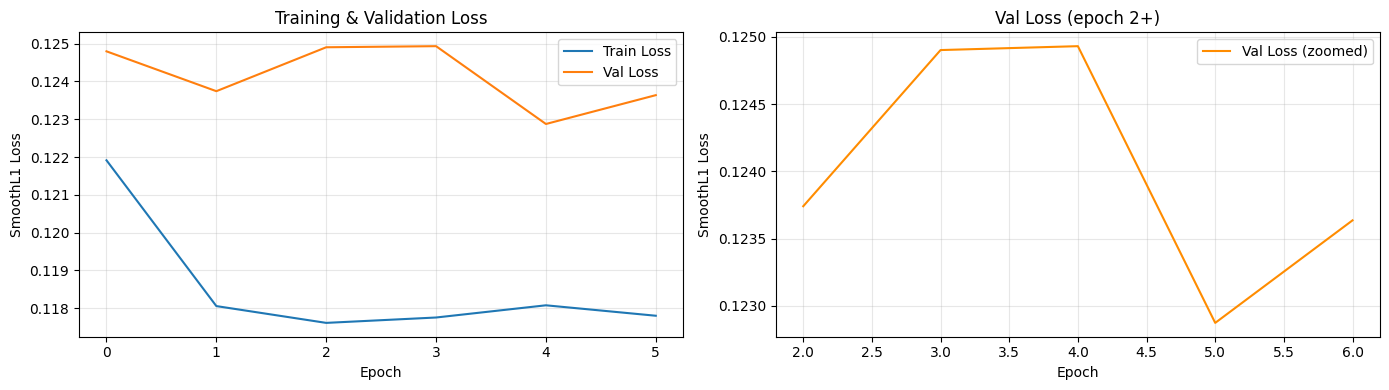

[OK] Loss curve saved → /kaggle/working/lstm_loss_curve.png

--- Generating eval predictions on 1000 sample IDs ---

LSTM EVALUATION — PER FORECAST HORIZON
Horizon    MAE   RMSE     R2  MAPE (%)  WRMSSE Proxy  N_samples
  7-day 0.9533 2.1050 0.5825 60.509998        1.7080       7000
 14-day 0.9705 2.2662 0.5495 60.450001        1.8407      14000
 28-day 0.9671 2.2733 0.5547 61.610001        1.8267      28000

--- Building lstm_predictions.csv ---

[OK] Saved: /kaggle/working/lstm_predictions.csv
  Shape  : (28000, 14)
  Columns: ['id', 'd', 'd_num', 'date', 'item_id', 'store_id', 'cat_id', 'dept_id', 'state_id', 'sales', 'xgb_pred', 'residual', 'horizon', 'lstm_pred']

  Horizon breakdown:
horizon
28-day    14000
14-day     7000
7-day      7000

  Sample rows:
                         id      d  d_num       date     item_id store_id cat_id dept_id state_id  sales  xgb_pred  residual horizon  lstm_pred
FOODS_1_001_CA_2_validation d_1886   1886 2016-03-28 FOODS_1_001     CA_2  FOODS FOOD

In [7]:
# =============================================================================
# SECTION 10 – MODEL  (EnhancedLSTM — architecture unchanged)
# =============================================================================
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size=52, hidden_size=256, num_layers=3,
                 num_heads=8, output_size=28, dropout=0.2,
                 cnn_channels=64, kernel_size=5):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.feature_proj = nn.Linear(input_size, hidden_size)
 
        self.lstms   = nn.ModuleList()
        self.ln_lstm = nn.ModuleList()
        for i in range(num_layers):
            self.lstms.append(nn.LSTM(
                input_size  = hidden_size * 2 if i > 0 else hidden_size,
                hidden_size = hidden_size,
                num_layers  = 1,
                batch_first = True,
                bidirectional = True,
            ))
            self.ln_lstm.append(nn.LayerNorm(hidden_size * 2))
 
        self.cnn = nn.Sequential(
            nn.Conv1d(hidden_size * 2, cnn_channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(cnn_channels), nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, 3, padding=1),
            nn.BatchNorm1d(cnn_channels), nn.ReLU(),
        )
        self.cnn_proj = nn.Linear(cnn_channels, hidden_size * 2)
 
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size * 2, num_heads=num_heads,
            batch_first=True, dropout=dropout,
        )
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(start_dim=1),
            nn.Linear(hidden_size * 2, hidden_size * 2 // 4), nn.ReLU(),
            nn.Linear(hidden_size * 2 // 4, hidden_size * 2), nn.Sigmoid(),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 4, 512), nn.LayerNorm(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),             nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, output_size),
            nn.Softplus(),
        )
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, p in m.named_parameters():
                    if "weight_ih" in name:   nn.init.xavier_uniform_(p)
                    elif "weight_hh" in name: nn.init.orthogonal_(p)
                    elif "bias" in name:      nn.init.zeros_(p)
 
    def forward(self, x):
        x = self.feature_proj(x)
        lstm_out = x
        for i, (lstm, ln) in enumerate(zip(self.lstms, self.ln_lstm)):
            out, _ = lstm(lstm_out)
            out     = ln(out)
            lstm_out = out if i == 0 else lstm_out + out
 
        cnn_out  = self.cnn(lstm_out.permute(0, 2, 1)).permute(0, 2, 1)
        combined = lstm_out + self.cnn_proj(cnn_out)
 
        attn_out, _ = self.attention(combined, combined, combined, need_weights=False)
        combined    = combined + attn_out
 
        se_w   = self.se(combined.permute(0, 2, 1)).unsqueeze(1)
        gated  = combined * se_w
 
        pooled = torch.cat([gated.mean(dim=1), gated.max(dim=1).values], dim=1)
        return self.head(pooled)
 
 
model = EnhancedLSTM(
    input_size  = n_feat,                  # 52 — from len(FEATURE_COLS)
    hidden_size = 256,
    num_layers  = 3,
    num_heads   = 8,
    output_size = HORIZON,             # 28
    dropout     = 0.2,
    cnn_channels = 64,
    kernel_size  = 5,
).to(DEVICE)
 
total_params = sum(p.numel() for p in model.parameters())
print(f"\n[OK] Model parameters: {total_params:,}")
 
# =============================================================================
# SECTION 11 – TRAINING LOOP  (optimised for speed + memory)
#
# IMPROVEMENTS OVER ORIGINAL:
#
#  Speed
#  ─────
#  1. torch.cuda.amp (AMP) — mixed-precision (fp16 forward/backward, fp32
#     master weights).  Typical speedup: 1.5–2× on Kaggle T4/P100.
#     GradScaler handles fp16 underflow transparently.
#
#  2. optimizer.zero_grad(set_to_none=True) — sets gradients to None instead
#     of zeroing them.  Eliminates the memset pass; ~5 % faster per step.
#
#  3. torch.compile(model) — TorchDynamo traces the model graph and emits
#     fused CUDA kernels (PyTorch ≥ 2.0).  First epoch slower (compilation),
#     subsequent epochs 10–30 % faster.  Falls back silently on CPU/old PyTorch.
#
#  4. OneCycleLR scheduler — single-cycle cosine LR with warm-up replaces
#     ReduceLROnPlateau.  Trains better in fewer epochs; no plateau wait.
#     Can be swapped back to ReduceLROnPlateau via USE_ONECYCLE = False.
#
#  5. Gradient accumulation (ACCUM_STEPS) — effective batch = BATCH × ACCUM.
#     Lets you run larger effective batches on limited VRAM without increasing
#     DL_BATCH_SIZE (which would increase DataLoader RAM usage).
#
#  Memory
#  ──────
#  6. torch.no_grad() + autocast in validate() — disables the autograd graph
#     during eval; combined with AMP, eval uses ~half the GPU memory.
#
#  7. Explicit del + torch.cuda.empty_cache() after each epoch — releases any
#     fragmented CUDA allocations left by the AMP scaler.
#
#  8. GradScaler with dynamic scaling — avoids fp16 overflow without storing
#     an extra fp32 copy of activations.
#
#  Robustness
#  ──────────
#  9. Resume from checkpoint — if a .pth already exists at checkpoint_path,
#     training resumes from that epoch rather than restarting.
#
# 10. Per-epoch timing + live throughput (samples/sec) printed for profiling.
# =============================================================================
 
import time
from torch.cuda.amp import GradScaler, autocast
 
# ── 11.0  Hyper-parameters ────────────────────────────────────────────────────
# ── Budget: STRIDE=14, SEQ_LEN=28, T4 GPU ────────────────────────────────────
# ~300K windows → ~9,400 batches/epoch at batch=32
# T4 throughput with AMP + compile ≈ 1,000–1,200 samples/sec
# Time/epoch ≈ 300K / 1,100 ≈ 4–5 min  →  18 epochs ≈ 75–90 min  ✓
EPOCHS        = 18
PATIENCE      = 4      # stop sooner — OneCycleLR converges faster than ReduceLR
CLIP_NORM     = 1.0
ACCUM_STEPS   = 1      # was 2; STRIDE=14 already gives clean gradient signal
                       # per step — no need to accumulate, saves one backward pass
USE_ONECYCLE  = True
BASE_LR       = 1e-4
MAX_LR        = 8e-4   # can push harder with STRIDE=14 (less noisy gradients)
WEIGHT_DECAY  = 1e-5
AMP_ENABLED   = DEVICE.type == "cuda"   # AMP only meaningful on GPU
 
# ── 11.1  torch.compile (PyTorch ≥ 2.0, GPU only) ────────────────────────────
_torch_major = int(torch.__version__.split(".")[0])
if _torch_major >= 2 and DEVICE.type == "cuda":
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("[OK] torch.compile: model compiled (reduce-overhead mode)")
    except Exception as _e:
        print(f"[WARN] torch.compile skipped: {_e}")
else:
    print(f"[INFO] torch.compile skipped  "
          f"(torch={torch.__version__}, device={DEVICE.type})")
 
 
# ── 11.2  Loss / optimiser / scheduler ───────────────────────────────────────
criterion = nn.SmoothL1Loss(beta=1.0)
 
optimizer = torch.optim.AdamW(
    model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY,
    fused=DEVICE.type == "cuda",   # fused AdamW kernel: ~10 % faster on GPU
)
 
if USE_ONECYCLE:
    # Steps per epoch = ceil(N / (batch × accum)) — matches what the loop sees
    steps_per_epoch = (len(train_loader) + ACCUM_STEPS - 1) // ACCUM_STEPS
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr          = MAX_LR,
        epochs          = EPOCHS,
        steps_per_epoch = steps_per_epoch,
        pct_start       = 0.3,          # 30 % warm-up, 70 % cosine decay
        anneal_strategy = "cos",
        div_factor      = MAX_LR / BASE_LR,
        final_div_factor= 1e4,
    )
    print(f"[OK] OneCycleLR  max_lr={MAX_LR:.0e}  "
          f"steps_per_epoch={steps_per_epoch}  total_steps={steps_per_epoch * EPOCHS}")
else:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )
    print("[OK] ReduceLROnPlateau")
 
scaler = GradScaler(enabled=AMP_ENABLED)
print(f"[OK] AMP mixed-precision : {AMP_ENABLED}  "
      f"(fp16 forward/backward on GPU, fp32 master weights)")
print(f"[OK] Gradient accumulation: {ACCUM_STEPS} steps  "
      f"(effective batch = {DL_BATCH_SIZE * ACCUM_STEPS})")
 
 
# ── 11.3  train_one_epoch ─────────────────────────────────────────────────────
def train_one_epoch(
    model, loader, optimizer, criterion, scaler,
    device, clip_norm=1.0, accum_steps=1, scheduler=None,
    use_onecycle=False,
):
    """
    One full pass over the training DataLoader.
 
    Returns
    -------
    avg_loss   : float  — mean SmoothL1 loss over all batches
    throughput : float  — samples processed per second
    """
    model.train()
    running_loss  = 0.0
    n_batches     = len(loader)
    t0            = time.perf_counter()
    total_samples = 0
 
    optimizer.zero_grad(set_to_none=True)   # clear before first accumulation step
 
    for step, (X, y) in enumerate(loader):
        X = X.to(device, non_blocking=True)   # non_blocking: overlaps H→D transfer
        y = y.to(device, non_blocking=True)   # with compute on previous batch
 
        # ── Forward pass under AMP ───────────────────────────────────────────
        with autocast(enabled=AMP_ENABLED):
            loss = criterion(model(X), y)
            loss = loss / accum_steps          # scale loss for accumulation
 
        # ── Backward pass (GradScaler handles fp16 underflow) ────────────────
        scaler.scale(loss).backward()
 
        running_loss  += loss.item() * accum_steps   # un-scale for logging
        total_samples += X.size(0)
 
        # ── Optimiser step every accum_steps batches ─────────────────────────
        if (step + 1) % accum_steps == 0 or (step + 1) == n_batches:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
 
            # OneCycleLR steps once per optimiser update, not per batch
            if use_onecycle and scheduler is not None:
                scheduler.step()
 
    elapsed    = time.perf_counter() - t0
    throughput = total_samples / elapsed
    return running_loss / n_batches, throughput
 
 
# ── 11.4  validate ────────────────────────────────────────────────────────────
def validate(model, loader, criterion, device):
    """
    Evaluation pass — no gradients, AMP enabled to match training dtype.
 
    Returns avg loss over the loader.
    """
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with autocast(enabled=AMP_ENABLED):
                running_loss += criterion(model(X), y).item()
    return running_loss / len(loader)
 
 
# ── 11.5  train_model ────────────────────────────────────────────────────────
def train_model(
    model, train_loader, val_loader,
    optimizer, scheduler, criterion, scaler,
    device,
    epochs          = 20,
    patience        = 5,
    clip_norm       = 1.0,
    accum_steps     = 1,
    use_onecycle    = False,
    checkpoint_path = "/kaggle/working/best_lstm_model.pth",
):
    """
    Full training loop with:
      • AMP + gradient accumulation
      • OneCycleLR or ReduceLROnPlateau
      • Early stopping on val loss
      • Auto-resume from an existing checkpoint
      • Per-epoch timing and throughput logging
    """
    best_val    = float("inf")
    wait        = 0
    start_epoch = 1
    train_hist, val_hist = [], []
 
    # ── Auto-resume ──────────────────────────────────────────────────────────
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        best_val    = ckpt.get("best_val_loss", float("inf"))
        start_epoch = ckpt.get("epoch", 0) + 1
        print(f"[RESUME] Loaded checkpoint from epoch {start_epoch - 1}  "
              f"(best_val={best_val:.4f})")
    else:
        print(f"[START] Training from scratch  (checkpoint → {checkpoint_path})")
 
    print("─" * 75)
    print(f"{'Epoch':>5}  {'Train':>8}  {'Val':>8}  {'LR':>9}  "
          f"{'Samp/s':>8}  {'Time':>6}  Status")
    print("─" * 75)
 
    for epoch in range(start_epoch, epochs + 1):
        t_epoch = time.perf_counter()
 
        # ── Train ─────────────────────────────────────────────────────────────
        tr_loss, throughput = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler,
            device, clip_norm=clip_norm, accum_steps=accum_steps,
            scheduler=scheduler if use_onecycle else None,
            use_onecycle=use_onecycle,
        )
 
        # ── Validate ──────────────────────────────────────────────────────────
        va_loss = validate(model, val_loader, criterion, device)
 
        # ── Plateau scheduler steps on val loss (not OneCycleLR) ─────────────
        if not use_onecycle:
            scheduler.step(va_loss)
 
        train_hist.append(tr_loss)
        val_hist.append(va_loss)
 
        lr      = optimizer.param_groups[0]["lr"]
        elapsed = time.perf_counter() - t_epoch
 
        # ── Early stopping + checkpoint ───────────────────────────────────────
        if va_loss < best_val:
            status   = "✅ best"
            best_val = va_loss
            wait     = 0
            torch.save({
                "epoch"           : epoch,
                "model_state_dict": model.state_dict(),
                "best_val_loss"   : best_val,
                "optimizer_state" : optimizer.state_dict(),
                "scaler_state"    : scaler.state_dict(),
            }, checkpoint_path)
        else:
            wait  += 1
            status = f"⏳ {wait}/{patience}"
            if wait >= patience:
                print(f"  → Early stopping at epoch {epoch}  "
                      f"(no improvement for {patience} epochs)")
                break
 
        print(f"{epoch:>5d}  {tr_loss:>8.4f}  {va_loss:>8.4f}  {lr:>9.2e}  "
              f"{throughput:>8.0f}  {elapsed:>5.1f}s  {status}")
 
        # Free fragmented CUDA allocations after every epoch
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
 
    print("─" * 75)
 
    # ── Load best weights ─────────────────────────────────────────────────────
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"✅ Restored best weights from epoch {ckpt['epoch']}  "
          f"(val_loss={ckpt['best_val_loss']:.4f})")
 
    return train_hist, val_hist, best_val
 
 
# ── 11.6  Run training ────────────────────────────────────────────────────────
train_hist, val_hist, best_loss = train_model(
    model, train_loader, eval_loader,
    optimizer, scheduler, criterion, scaler,
    device          = DEVICE,
    epochs          = EPOCHS,
    patience        = PATIENCE,
    clip_norm       = CLIP_NORM,
    accum_steps     = ACCUM_STEPS,
    use_onecycle    = USE_ONECYCLE,
    checkpoint_path = str(OUTPUT_DIR / "best_lstm_model.pth"),
)
 
print(f"\n[OK] Training complete  best_val_loss={best_loss:.4f}")
 
 
# ── 11.7  Loss curve ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Loss
axes[0].plot(train_hist, label="Train Loss", linewidth=1.5)
axes[0].plot(val_hist,   label="Val Loss",   linewidth=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("SmoothL1 Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
 
# Val loss zoom — exclude epoch 1 (often a spike)
if len(val_hist) > 2:
    axes[1].plot(range(2, len(val_hist) + 1), val_hist[1:],
                 label="Val Loss (zoomed)", color="darkorange", linewidth=1.5)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("SmoothL1 Loss")
    axes[1].set_title("Val Loss (epoch 2+)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lstm_loss_curve.png", dpi=150)
plt.show()
print(f"[OK] Loss curve saved → {OUTPUT_DIR / 'lstm_loss_curve.png'}")
 
 
# =============================================================================
# SECTION 12 – EVALUATION AT 7 / 14 / 28 DAY HORIZONS
# Mirrors the exact horizon bucketing in teammate's section 4.2.
# Validation period: d_1886–d_1913 (28 days).
#   • 7-day  bucket: last 7 of the 28 days  (d_1907–d_1913)
#   • 14-day bucket: last 14 of the 28 days (d_1900–d_1913)
#   • 28-day bucket: all 28 days            (d_1886–d_1913)
# This exactly matches teammate's horizon label convention.
# =============================================================================
print("\n--- Generating eval predictions on 1000 sample IDs ---")
model.eval()
all_preds, all_targets = [], []
 
with torch.no_grad():
    for X_b, y_b in eval_loader:
        preds = model(X_b.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_b.numpy())
 
preds_log   = np.concatenate(all_preds,   axis=0)   # (1000, 28) — log scale
targets_log = np.concatenate(all_targets, axis=0)
 
# Reverse log1p → original sales scale
preds_orig   = np.expm1(preds_log).clip(0)
targets_orig = np.expm1(targets_log)
 
def compute_metrics(y_true_flat, y_pred_flat, label):
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mae  = mean_absolute_error(y_true_flat, y_pred_flat)
    r2   = r2_score(y_true_flat, y_pred_flat)
    mask = y_true_flat > 0
    mape = (np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask]).mean() * 100
            if mask.sum() > 0 else float("nan"))
    wrmsse = rmse / (y_true_flat.mean() + 1e-8)
    return {"Horizon": label, "MAE": round(mae,4), "RMSE": round(rmse,4),
            "R2": round(r2,4), "MAPE (%)": round(mape,2),
            "WRMSSE Proxy": round(wrmsse,4), "N_samples": len(y_true_flat)}
 
# Horizon slices: columns 0..H of the (n_items, 28) prediction matrix
HORIZONS = {
    "7-day" : slice(21, 28),   # last 7  of 28 columns → d_1907–d_1913
    "14-day": slice(14, 28),   # last 14 of 28 columns → d_1900–d_1913
    "28-day": slice(0,  28),   # all 28              → d_1886–d_1913
}
 
metrics_rows = []
for label, sl in HORIZONS.items():
    t_flat = targets_orig[:, sl].flatten()
    p_flat = preds_orig[:, sl].flatten()
    metrics_rows.append(compute_metrics(t_flat, p_flat, label))
 
metrics_df = pd.DataFrame(metrics_rows)
print("\n" + "=" * 70)
print("LSTM EVALUATION — PER FORECAST HORIZON")
print("=" * 70)
print(metrics_df.to_string(index=False))
metrics_df.to_csv(OUTPUT_DIR / "lstm_metrics.csv", index=False)
 
# =============================================================================
# SECTION 13 – BUILD ENSEMBLE-READY PREDICTIONS CSV
# Output format mirrors xgb_predictions.csv exactly, plus lstm_pred column.
# Join key: (id, d_num)  — same as XGBoost output.
# =============================================================================
print("\n--- Building lstm_predictions.csv ---")
 
# eval_meta: one row per (id, d_num) for the 1000 eval products × 28 days
eval_meta_df     = pd.DataFrame(eval_meta)
item_ids_ordered = eval_meta_df.drop_duplicates("id")["id"].tolist()
n_items          = len(item_ids_ordered)
 
rows = []
for i, item_id in enumerate(item_ids_ordered):
    for day_offset in range(HORIZON):
        rows.append({
            "id"       : item_id,
            "d_num"    : VAL_START_DAY + day_offset,
            "lstm_pred": round(float(preds_orig[i, day_offset]), 4),
            "actual"   : round(float(targets_orig[i, day_offset]), 4),
        })
 
lstm_df = pd.DataFrame(rows)
 
# ── Merge with XGBoost predictions on (id, d_num) ──────────────────────────
# xgb_preds already loaded in Section 1
ensemble_df = xgb_preds.merge(
    lstm_df[["id", "d_num", "lstm_pred"]],
    on=["id", "d_num"],
    how="left",
)
assert ensemble_df["lstm_pred"].isna().sum() == 0, \
    "⚠️  Some rows in xgb_predictions.csv have no matching LSTM prediction!"
 
# Tag horizons (consistent with teammate's bucketing)
d_max = ensemble_df["d_num"].max()
ensemble_df["horizon"] = "28-day"
ensemble_df.loc[ensemble_df["d_num"] > (d_max - 14), "horizon"] = "14-day"
ensemble_df.loc[ensemble_df["d_num"] > (d_max - 7),  "horizon"] = "7-day"
 
# Save
out_path = OUTPUT_DIR / "lstm_predictions.csv"
ensemble_df.to_csv(out_path, index=False)
 
print(f"\n[OK] Saved: {out_path}")
print(f"  Shape  : {ensemble_df.shape}")
print(f"  Columns: {ensemble_df.columns.tolist()}")
print(f"\n  Horizon breakdown:")
print(ensemble_df["horizon"].value_counts().to_string())
print(f"\n  Sample rows:")
print(ensemble_df.head(5).to_string(index=False))

In [8]:
print("\n" + "=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)
print(f"  Feature columns  : {len(FEATURE_COLS)} (identical to XGBoost teammate)")
print(f"  Sequence length  : {SEQ_LEN} days lookback")
print(f"  Horizon          : {HORIZON} days")
print(f"  Train products   : {len(TRAIN_IDS)} (sequences used for model training)")
print(f"  Eval  products   : {n_items} (1000 sample IDs from xgb_predictions.csv)")
print(f"  Ensemble join key: (id, d_num)")
print()
print("  LSTM per-horizon results:")
for _, row in metrics_df.iterrows():
    print(f"    {row['Horizon']:>8s}  |  "
          f"MAE={row['MAE']:.4f}  RMSE={row['RMSE']:.4f}  "
          f"R2={row['R2']:.4f}  MAPE={row['MAPE (%)']:.1f}%")
print()
print("  Files saved:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"    {f.name}")
print("=" * 70)
print("✅ LSTM pipeline complete — ready to pass lstm_predictions.csv to Gating Network!")


PIPELINE SUMMARY
  Feature columns  : 52 (identical to XGBoost teammate)
  Sequence length  : 28 days lookback
  Horizon          : 28 days
  Train products   : 14000 (sequences used for model training)
  Eval  products   : 1000 (1000 sample IDs from xgb_predictions.csv)
  Ensemble join key: (id, d_num)

  LSTM per-horizon results:
       7-day  |  MAE=0.9533  RMSE=2.1050  R2=0.5825  MAPE=60.5%
      14-day  |  MAE=0.9705  RMSE=2.2662  R2=0.5495  MAPE=60.5%
      28-day  |  MAE=0.9671  RMSE=2.2733  R2=0.5547  MAPE=61.6%

  Files saved:
    .virtual_documents
    best_lstm_model.pth
    lstm_loss_curve.png
    lstm_metrics.csv
    lstm_predictions.csv
✅ LSTM pipeline complete — ready to pass lstm_predictions.csv to Gating Network!
